---

# Optimization Algorithms 

---

In this exercise, you will implement several optimization algorithms from the lecture.

The goal is to understand how neural network parameters are updated after backpropagation computes gradients.

We will use PyTorch autograd to compute gradients, but you will implement the optimizer update rules yourself.

The optimizers are:

- Stochastic Gradient Descent
- Stochastic Gradient Descent with Momentum
- AdaGrad
- RMSProp
- Adam
- AdamW

The model itself is provided in `model.py`. It is a small MLP. The focus of this exercise is the optimization logic.

---

## Why Do We Need Optimizers?

---

A neural network contains parameters such as weights and biases. During training, we want to find parameter values that minimize a loss function.

For parameters $\theta$, the loss is usually written as:

$$
\mathcal{L}(\theta)
$$

Backpropagation computes gradients:

$$
\nabla_\theta \mathcal{L}(\theta)
$$

The gradient tells us the direction in which the loss increases most quickly. To reduce the loss, we move in the opposite direction.

The simplest update rule is:

$$
\theta_{t+1} = \theta_t - \eta \nabla_\theta \mathcal{L}(\theta_t)
$$

where $\eta$ is the learning rate.

Different optimizers mainly differ in how they transform, smooth, rescale, or regularize this update.

---

## Optimizer State

---

Some optimizers only need the current parameter values and current gradients.

For example, plain SGD does not need to remember anything from previous steps.

Other optimizers need additional memory, called **optimizer state**.

Examples:
- Momentum stores a velocity vector.
- AdaGrad stores accumulated squared gradients.
- RMSProp stores a moving average of squared gradients.
- Adam and AdamW store first moment estimates and second moment estimates.

This is why some optimizers need an `init_...` function.

The init function creates tensors with the same shapes as the model parameters, usually initialized to zero.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
import optimizers
import tests
import train as train_module
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on {device}")

Running on cpu


---

# Stochastic Gradient Descent

---

Before implementing SGD, we also need a small helper function.

During training, PyTorch stores gradients in `param.grad`. These gradients accumulate by default. Therefore, before every new backward pass, we have to reset old gradients to zero.

This is what `zero_grad` does.

SGD then updates each parameter by moving in the negative gradient direction:

$$
\theta_{t+1} = \theta_t - \eta g_t
$$

where

$$
g_t = \nabla_\theta \mathcal{L}(\theta_t)
$$

and $\eta$ is the learning rate.

SGD uses the same global learning rate for every parameter. This makes it simple, but it can be sensitive to the scale of different features and gradients.

---

## **Task:**

Implement:

- `zero_grad`
- `sgd_step`

in `optimizers.py`.

**Hints:**
- The list elements of `params` are usually matrices (weights) or vectors (biases), or to put simply: tensors.
- Each list element (`param`) has a variable `grad` accessible via `param.grad`.
- Only update parameters whose `param.grad` is not `None`.
- Use `torch.no_grad()` when changing parameters manually.
- `zero_grad` should zero existing gradients, but it should not create new gradients.
- `tensor.zero_()` and `torch.zeros_like` can be helpful.

In [6]:
tests.test_sgd()

✅ PASS: zero_grad is correct.
✅ PASS: sgd_step is correct.

🎉 SGD tests passed.


True

---

# SGD with Momentum

---

SGD with momentum adds memory to the update.

Instead of using only the current gradient, it keeps a running velocity:

$$
v_{t+1} = \beta v_t - \eta g_t
$$

The parameters are then updated using:

$$
\theta_{t+1} = \theta_t + v_{t+1}
$$

where:

- $\beta$ is the momentum coefficient
- $v_t$ is the velocity
- $\eta$ is the learning rate

Momentum can speed up training in directions where gradients consistently point the same way. It can also reduce oscillations.

---

Momentum needs to remember one velocity tensor for every parameter tensor.

At the beginning of training, all velocities are zero:

$$
v_0 = 0
$$

The function `init_momentum` creates these zero tensors.

---

## **Task:**

Implement:

- `init_momentum`
- `sgd_momentum_step`

in `optimizers.py`.


**Hints:**
- The velocity state should have the same shapes as the parameters.
- First update the velocity, then update the parameter.
- Notice that the parameter update uses `+ velocity`, not `- velocity`.

In [9]:
tests.test_sgd_momentum()

✅ PASS: init_momentum is correct.
✅ PASS: sgd_momentum_step is correct.

🎉 SGD with momentum tests passed.


True

---

# AdaGrad

---

AdaGrad gives each parameter its own adaptive learning rate.

Some parameters may receive large gradients often. Other parameters may receive small gradients or only change occasionally. Using one global learning rate for all parameters can therefore be inefficient.

AdaGrad stores the accumulated squared gradients:

$$
G_{t+1} = G_t + g_t^2
$$

where the square is elementwise and

$$
g_t = \nabla_\theta \mathcal{L}(\theta_t).
$$

The parameter update is:

$$
\theta_{t+1}
=
\theta_t
-
\frac{\eta}{\sqrt{G_{t+1}} + \epsilon}
g_t
$$

where:

- $G_t$ stores the accumulated squared gradients
- $\eta$ is the learning rate
- $\epsilon$ is a small constant for numerical stability

Parameters with large accumulated gradients get smaller effective updates. Parameters with small accumulated gradients get larger effective updates.

The downside is that $G_t$ only grows over time. Therefore, the effective learning rate can become very small.

---

AdaGrad needs to remember one accumulated squared-gradient tensor for every parameter tensor.

At the beginning of training, all accumulated squared gradients are zero:

$$
G_0 = 0
$$

The function `init_adagrad` creates these zero tensors.

---

## **Task:**

Implement:

- `init_adagrad`
- `adagrad_step`

in `optimizers.py`.

**Hints:**

- `G` should be a list with one tensor per parameter.
- Use `torch.zeros_like(param)` when initializing the state.
- The square `grad * grad` is elementwise.
- Add `eps` after the square root, not before.

In [11]:
tests.test_adagrad()

✅ PASS: init_adagrad is correct.
✅ PASS: adagrad_step is correct.

🎉 AdaGrad tests passed.


True

---

# RMSProp

---

RMSProp fixes one of AdaGrad's main problems.

In AdaGrad, the accumulated squared gradients only grow. This means the effective learning rate keeps shrinking.

RMSProp replaces the cumulative sum with an exponentially weighted moving average:

$$
G_{t+1}
=
\gamma G_t
+
(1 - \gamma) g_t^2
$$

where:

- $G_t$ stores the moving average of squared gradients
- $\gamma$ is the decay factor
- $g_t = \nabla_\theta \mathcal{L}(\theta_t)$

The parameter update is:

$$
\theta_{t+1}
=
\theta_t
-
\frac{\eta}{\sqrt{G_{t+1}} + \epsilon}
g_t
$$

This is similar to AdaGrad, but old gradients are gradually forgotten.

Therefore, the learning rate can recover if a parameter's gradients become small again.

---

RMSProp needs to remember one moving-average tensor for every parameter tensor.

At the beginning of training, all moving averages are zero:

$$
G_0 = 0
$$

The function `init_rmsprop` creates these zero tensors.

---

## **Task:**

Implement:

- `init_rmsprop`
- `rmsprop_step`

in `optimizers.py`.

**Hints:**

- The state has the same structure as AdaGrad: one tensor per parameter.
- The difference is the update of `G`.
- AdaGrad uses a cumulative sum; RMSProp uses an exponential moving average.
- `gamma` controls how much of the old state is kept.


In [13]:
tests.test_rmsprop()

✅ PASS: init_rmsprop is correct.
✅ PASS: rmsprop_step is correct.

🎉 RMSProp tests passed.


True

---

# Adam

---

Adam combines two ideas:

1. Momentum-like smoothing of gradients
2. Adaptive learning rates for each parameter

Adam stores a running average of gradients:

$$
m_{t+1}
=
\beta_1 m_t
+
(1 - \beta_1) g_t
$$

and a running average of squared gradients:

$$
v_{t+1}
=
\beta_2 v_t
+
(1 - \beta_2) g_t^2
$$

Because both $m_0$ and $v_0$ are initialized at zero, Adam uses bias correction:

$$
\hat{m}_{t+1}
=
\frac{m_{t+1}}{1 - \beta_1^{t+1}}
$$

$$
\hat{v}_{t+1}
=
\frac{v_{t+1}}{1 - \beta_2^{t+1}}
$$

The update is:

$$
\theta_{t+1}
=
\theta_t
-
\frac{\eta}{\sqrt{\hat{v}_{t+1}} + \epsilon}
\hat{m}_{t+1}
$$

---

Adam needs to remember three pieces of state:

- `m`: first moment estimates
- `v`: second moment estimates
- `t`: timestep counter

The function `init_adam` creates zero tensors for `m` and `v`, and sets `t = 0`.

---

## **Task:**

Implement:

- `init_adam`
- `adam_step`

in `optimizers.py`.

**Hints:**

- `m`, `v`, and `t` all belong to the optimizer state.
- Increment `t` before computing the bias-correction terms.
- `m` stores gradients, while `v` stores squared gradients.
- The square root is applied to the bias-corrected second moment.


In [16]:
tests.test_adam()

✅ PASS: init_adam is correct.
✅ PASS: adam_step is correct.

🎉 Adam tests passed.


True

---

# AdamW

---

AdamW is a variant of Adam that changes how weight decay is applied.

Weight decay encourages smaller parameter values. This can improve generalization and reduce overfitting.

In AdamW, weight decay is **decoupled** from the gradient update.

The update can be written as:

$$
\theta_{t+1}
=
\theta_t
-
\frac{\eta}{\sqrt{\hat v_{t+1}} + \epsilon}
\hat m_{t+1}
-
\eta \lambda \theta_t
$$

Here, $\lambda$ is the weight decay coefficient.

This is different from adding an L2 penalty directly to the gradient. For adaptive optimizers such as Adam, decoupled weight decay often behaves more predictably.

AdamW uses the same state as Adam:

- first moment estimates `m`
- second moment estimates `v`
- timestep `t`

So we can reuse `init_adam`.

---

## **Task:**

Implement `adamw_step` in `optimizers.py`.

You can reuse most of your Adam implementation.

**Hints:**

- AdamW reuses the same state as Adam.
- The Adam part of the update is almost identical to `adam_step`.
- Weight decay should be applied directly to the parameter, not added to the gradient.


In [18]:
tests.test_adamw()

✅ PASS: init_adam is correct.
✅ PASS: adamw_step is correct.

🎉 AdamW tests passed.


True

---

# Training Comparison

---

Now we compare the optimizers on a small MLP.

The dataset is synthetic and fast to train on.
It is intentionally designed to make optimization difficult for methods with one global learning rate.

The informative features have different scales and some of them are sparse. This favors optimizers such as AdaGrad, RMSProp, Adam, and AdamW, which adapt the effective learning rate separately for each parameter.

Therefore, the comparison below should **not be read as a universal ranking of optimizers**!  
On other datasets, and with enough tuning, SGD with Momentum can be very competitive.

The goal here is to illustrate a situation where adaptive optimizers are especially useful.

We will compare:

- training loss
- test accuracy
- parameter norm

---

## Parameter Norm

Besides training loss and test accuracy, we also track the parameter norm.

If all trainable parameters are collected into one large vector

$$
\theta =
\begin{bmatrix}
\theta_1, \theta_2, \dots, \theta_n
\end{bmatrix}
$$

then the L2 parameter norm is

$$
\|\theta\|_2 =
\sqrt{
\sum_{i=1}^{n} \theta_i^2
}
$$

Weight decay encourages smaller parameter values. Therefore, AdamW should often have a smaller parameter norm than Adam, even when their training loss and accuracy are similar.

---

In [4]:
# Hyperparameters, DON'T CHANGE.
epochs      = 50
batch_size  = 64
print_every = 5

In [5]:
sgd_results = train_module.run_experiment(
    optimizer_name="sgd",
    zero_grad_fn=optimizers.zero_grad,
    optimizer_step_fn=optimizers.sgd_step,
    init_state_fn=None,
    optimizer_kwargs={
        "learning_rate": 0.25
    },
    epochs=epochs,
    batch_size=batch_size,
    device=device,
    print_every=print_every
)

sgd | epoch 01/50 | loss 1.1071 | acc 33.89% | norm 9.36
sgd | epoch 05/50 | loss 0.9340 | acc 38.33% | norm 9.43
sgd | epoch 10/50 | loss 0.6943 | acc 35.00% | norm 9.65
sgd | epoch 15/50 | loss 0.3938 | acc 38.89% | norm 9.98
sgd | epoch 20/50 | loss 0.3709 | acc 38.33% | norm 10.29
sgd | epoch 25/50 | loss 0.0879 | acc 40.56% | norm 10.55
sgd | epoch 30/50 | loss 0.0428 | acc 44.44% | norm 10.72
sgd | epoch 35/50 | loss 0.0276 | acc 43.89% | norm 10.83
sgd | epoch 40/50 | loss 0.0187 | acc 43.89% | norm 10.91
sgd | epoch 45/50 | loss 0.0138 | acc 46.11% | norm 10.97
sgd | epoch 50/50 | loss 0.0109 | acc 46.11% | norm 11.03


In [6]:
sgd_momentum_results = train_module.run_experiment(
    optimizer_name="sgd_momentum",
    zero_grad_fn=optimizers.zero_grad,
    optimizer_step_fn=optimizers.sgd_momentum_step,
    init_state_fn=optimizers.init_momentum,
    optimizer_kwargs={
        "learning_rate": 0.1,
        "momentum": 0.8
    },
    epochs=epochs,
    batch_size=batch_size,
    device=device,
    print_every=print_every
)

sgd_momentum | epoch 01/50 | loss 1.1127 | acc 35.56% | norm 9.36
sgd_momentum | epoch 05/50 | loss 0.8759 | acc 37.78% | norm 9.48
sgd_momentum | epoch 10/50 | loss 0.3904 | acc 40.00% | norm 10.03
sgd_momentum | epoch 15/50 | loss 0.0882 | acc 41.11% | norm 10.67
sgd_momentum | epoch 20/50 | loss 0.0189 | acc 43.89% | norm 10.99
sgd_momentum | epoch 25/50 | loss 0.0093 | acc 46.67% | norm 11.12
sgd_momentum | epoch 30/50 | loss 0.0062 | acc 47.22% | norm 11.20
sgd_momentum | epoch 35/50 | loss 0.0047 | acc 49.44% | norm 11.26
sgd_momentum | epoch 40/50 | loss 0.0037 | acc 49.44% | norm 11.31
sgd_momentum | epoch 45/50 | loss 0.0031 | acc 50.00% | norm 11.34
sgd_momentum | epoch 50/50 | loss 0.0026 | acc 50.00% | norm 11.38


In [7]:
adagrad_results = train_module.run_experiment(
    optimizer_name="adagrad",
    zero_grad_fn=optimizers.zero_grad,
    optimizer_step_fn=optimizers.adagrad_step,
    init_state_fn=optimizers.init_adagrad,
    optimizer_kwargs={
        "learning_rate": 3e-2,
        "eps": 1e-8
    },
    epochs=epochs,
    batch_size=batch_size,
    device=device,
    print_every=print_every
)

adagrad | epoch 01/50 | loss 1.7642 | acc 38.89% | norm 10.60
adagrad | epoch 05/50 | loss 0.5322 | acc 58.33% | norm 12.44
adagrad | epoch 10/50 | loss 0.0332 | acc 81.11% | norm 14.08
adagrad | epoch 15/50 | loss 0.0090 | acc 83.33% | norm 14.48
adagrad | epoch 20/50 | loss 0.0046 | acc 84.44% | norm 14.69
adagrad | epoch 25/50 | loss 0.0030 | acc 84.44% | norm 14.82
adagrad | epoch 30/50 | loss 0.0021 | acc 85.56% | norm 14.92
adagrad | epoch 35/50 | loss 0.0016 | acc 86.67% | norm 15.00
adagrad | epoch 40/50 | loss 0.0013 | acc 86.67% | norm 15.06
adagrad | epoch 45/50 | loss 0.0011 | acc 86.67% | norm 15.11
adagrad | epoch 50/50 | loss 0.0009 | acc 87.78% | norm 15.16


In [8]:
rmsprop_results = train_module.run_experiment(
    optimizer_name="rmsprop",
    zero_grad_fn=optimizers.zero_grad,
    optimizer_step_fn=optimizers.rmsprop_step,
    init_state_fn=optimizers.init_rmsprop,
    optimizer_kwargs={
        "learning_rate": 1e-2,
        "gamma": 0.95,
        "eps": 1e-8
    },
    epochs=epochs,
    batch_size=batch_size,
    device=device,
    print_every=print_every
)

rmsprop | epoch 01/50 | loss 2.8733 | acc 36.11% | norm 12.06
rmsprop | epoch 05/50 | loss 0.5535 | acc 66.11% | norm 14.17
rmsprop | epoch 10/50 | loss 0.0125 | acc 87.78% | norm 15.88
rmsprop | epoch 15/50 | loss 0.0032 | acc 87.78% | norm 16.28
rmsprop | epoch 20/50 | loss 0.0013 | acc 90.56% | norm 16.54
rmsprop | epoch 25/50 | loss 0.0007 | acc 90.56% | norm 16.74
rmsprop | epoch 30/50 | loss 0.0004 | acc 91.11% | norm 16.91
rmsprop | epoch 35/50 | loss 0.0002 | acc 92.22% | norm 17.06
rmsprop | epoch 40/50 | loss 0.0001 | acc 92.22% | norm 17.20
rmsprop | epoch 45/50 | loss 0.0001 | acc 92.78% | norm 17.33
rmsprop | epoch 50/50 | loss 0.0000 | acc 93.33% | norm 17.45


In [9]:
adam_results = train_module.run_experiment(
    optimizer_name="adam",
    zero_grad_fn=optimizers.zero_grad,
    optimizer_step_fn=optimizers.adam_step,
    init_state_fn=optimizers.init_adam,
    optimizer_kwargs={
        "learning_rate": 3e-2,
        "beta1": 0.9,
        "beta2": 0.999,
        "eps": 1e-8
    },
    epochs=epochs,
    batch_size=batch_size,
    device=device,
    print_every=print_every
)

adam | epoch 01/50 | loss 1.6649 | acc 39.44% | norm 11.79
adam | epoch 05/50 | loss 0.7595 | acc 53.89% | norm 21.80
adam | epoch 10/50 | loss 0.0038 | acc 91.67% | norm 30.56
adam | epoch 15/50 | loss 0.0001 | acc 95.00% | norm 34.07
adam | epoch 20/50 | loss 0.0000 | acc 95.56% | norm 34.99
adam | epoch 25/50 | loss 0.0000 | acc 95.56% | norm 35.22
adam | epoch 30/50 | loss 0.0000 | acc 95.56% | norm 35.27
adam | epoch 35/50 | loss 0.0000 | acc 95.56% | norm 35.28
adam | epoch 40/50 | loss 0.0000 | acc 95.56% | norm 35.28
adam | epoch 45/50 | loss 0.0000 | acc 95.56% | norm 35.28
adam | epoch 50/50 | loss 0.0000 | acc 95.56% | norm 35.28


In [10]:
adamw_results = train_module.run_experiment(
    optimizer_name="adamw",
    zero_grad_fn=optimizers.zero_grad,
    optimizer_step_fn=optimizers.adamw_step,
    init_state_fn=optimizers.init_adam,
    optimizer_kwargs={
        "learning_rate": 3e-2,
        "beta1": 0.9,
        "beta2": 0.999,
        "eps": 1e-8,
        "weight_decay": 1e-2
    },
    epochs=epochs,
    batch_size=batch_size,
    device=device,
    print_every=print_every
)

adamw | epoch 01/50 | loss 1.6643 | acc 39.44% | norm 11.78
adamw | epoch 05/50 | loss 0.7606 | acc 54.44% | norm 21.74
adamw | epoch 10/50 | loss 0.0037 | acc 92.22% | norm 30.41
adamw | epoch 15/50 | loss 0.0000 | acc 96.67% | norm 33.79
adamw | epoch 20/50 | loss 0.0000 | acc 96.67% | norm 34.57
adamw | epoch 25/50 | loss 0.0000 | acc 96.67% | norm 34.64
adamw | epoch 30/50 | loss 0.0000 | acc 97.78% | norm 34.53
adamw | epoch 35/50 | loss 0.0000 | acc 97.78% | norm 34.39
adamw | epoch 40/50 | loss 0.0000 | acc 97.78% | norm 34.24
adamw | epoch 45/50 | loss 0.0000 | acc 97.78% | norm 34.09
adamw | epoch 50/50 | loss 0.0000 | acc 97.78% | norm 33.94


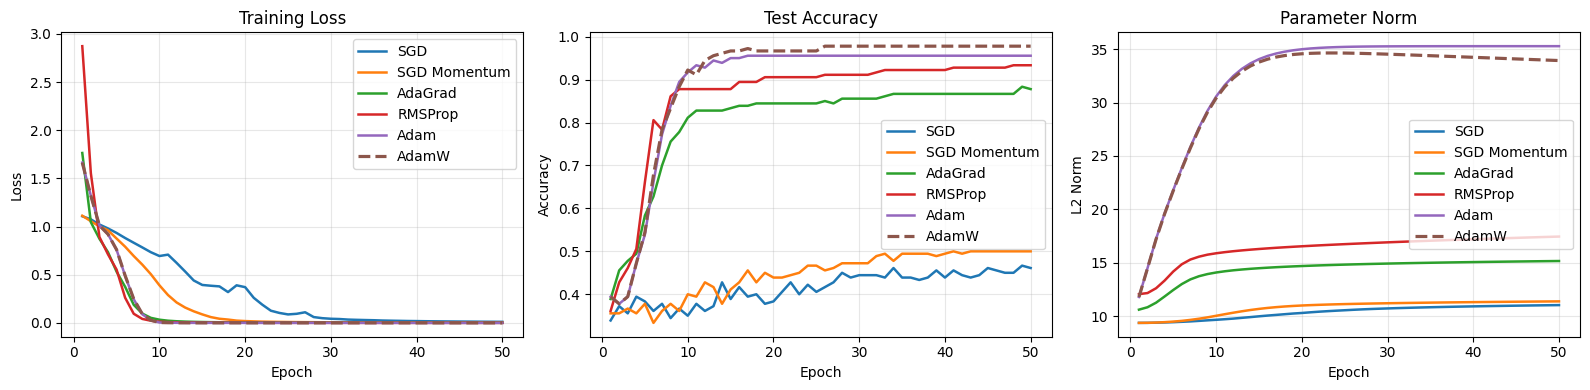

In [11]:
train_module.plot_results(
    [sgd_results, sgd_momentum_results, adagrad_results, rmsprop_results, adam_results, adamw_results],
    ["SGD", "SGD Momentum", "AdaGrad", "RMSProp", "Adam", "AdamW"],
)